In [32]:
#| default_exp methods.visualization

In [33]:
#| export
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import scipy.stats as stats
import networkx as nx

# Boxplot Summary

In [34]:
#| export

def simulation_boxplot_summary(data, 
                               param1_values, 
                               param2_values, 
                               title, 
                               ylabel, 
                               parameter_names = ['Paramter 1', 'Parameter 2'],
                               legend_loc = 2,
                               legend_cols = 3,
                               legend_fontsize = 12
                              ):
    '''
    data: 3D array, with simulation results. First two dimensions give value of a simulation parameter, third dimension gives the simulation number.
    '''


    
    A = np.shape(data)[0] #param1
    B = np.shape(data)[1] #param2
    C = np.shape(data)[2] #simulations
    # Define colors for B indices
    colors = plt.cm.viridis(np.linspace(0, 1, B))  # B distinct colors
    
    d = 3 #priming softmax index
    for b in range(B):
        box_data = [data[a, b, :] for a in range(A)]
        positions = np.arange(A) + (b - B / 2) * 0.1  # Adjust positions to avoid overlap
        plt.boxplot(box_data, positions=positions, widths=0.1, patch_artist=True, 
                    boxprops=dict(facecolor=colors[b], alpha=0.6), 
                    medianprops=dict(color='black'))
        # Calculate and add 95% credible interval error bars
        for a in range(A):
            mean_val = np.mean(data[a, b, :])
            ci_low, ci_high = stats.t.interval(0.95, df=C-1, loc=mean_val, scale=stats.sem(data[a, b, :]))
            plt.errorbar(positions[a], mean_val, yerr=[[mean_val - ci_low], [ci_high - mean_val]], fmt='o', color='black')
    
    # Create legend
    legend_patches = [plt.Line2D([0], [0], color=colors[b], lw=4, label=f'{parameter_names[1]}={param2_values[b]}') for b in range(B)]
    plt.legend(handles=legend_patches, loc = legend_loc, ncol = legend_cols, fontsize = legend_fontsize)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(parameter_names[0])
    plt.xticks(range(A), labels=[f"{param1_values[a]}" for a in range(A)])

In [35]:
#| export
from typing import Any
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np

def plot_heatmap(matrix: NDArray[np.float_], 
                 title: str ="Expectation of Memory Traces",    
                 xlabel: str ="Trace", 
                 ylabel: str ="Time Step", 
                 color:str ="Blues", 
                 extent:tuple[float,float,float,float] | None = None,           #sets limits of axis coordinats: [left, right, bottom, top]
                 figsize:tuple[float, float] =(8, 6),
                 xticks:list[float] | None = None,
                 xtick_labels:list[str] | None = None,
                 yticks:list[float] | None = None,
                 ytick_labels:list[str] | None = None,
                 ax: Axes|None =None,                                           #optional plt axis to draw plot on
                 vmin:float|None=None,                                          #minimum for heatmap colorscale
                 vmax:float|None=None,                                          #maximum for heatmap colorscale
                 label_scale:float=1.0,                                         #multiplier for label sizes
                 colorbar_kwargs: dict[str,Any] | None ={},                     #arguments to pass to colorbar function
                 category_sizes: list[int] | None = None,
                 **kwargs
                ):
    """
    Plots a heatmap of the given matrix using the intensity of a single color,
    allowing arbitrary colorbar arguments to be passed in as a dictionary.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        show = True
    else:
        fig = ax.figure
        show = False  # Don't show if plotting to existing axis

    nrows, ncols = matrix.shape

    # Set extent so each pixel spans [i, i+1] in axis coords
    if extent is None:
        extent = (0, ncols, nrows, 0)  # left, right, bottom, top

    im = ax.imshow(matrix, cmap=plt.colormaps.get_cmap(color), 
                   aspect='auto', extent=extent, vmin=vmin, vmax=vmax)

  
    ax.set_title(title, fontsize=kwargs.get('title_fontsize', 12* label_scale))
    ax.set_xlabel(xlabel, fontsize=kwargs.get('label_fontsize', 12* label_scale))
    ax.set_ylabel(ylabel, fontsize=kwargs.get('label_fontsize', 12* label_scale))
    ax.invert_yaxis()

    # Default xticks at centers
    if xticks is None:
        xticks = np.arange(ncols)
        ax.set_xticks(xticks + 0.5)
        # Use np.linspace to select at most 5 tick labels if ncols > 10
        if xtick_labels is None:
            if ncols > 10:
                idxs = np.linspace(0, ncols - 1, num=5, dtype=int)
                xtick_labels = [str(i+1) if i in idxs else "" for i in xticks]
            else:
                xtick_labels = [str(i+1) for i in xticks]
        ax.set_xticklabels(xtick_labels, fontsize=kwargs.get('tick_fontsize', 10* label_scale))
    else:
        ax.set_xticks(xticks)
        if xtick_labels is not None:
            ax.set_xticklabels(xtick_labels, fontsize=kwargs.get('tick_fontsize', 10* label_scale))

    # Default yticks at centers
    if yticks is None:
        yticks = np.arange(nrows)
        ax.set_yticks(yticks + 0.5)
        # Use np.linspace to select at most 5 tick labels if ncols > 10
        if ytick_labels is None:
            if nrows > 10:
                idxs = np.linspace(0, nrows - 1, num=5, dtype=int)
                ytick_labels = [str(i+1) if i in idxs else "" for i in yticks]
            else:
                ytick_labels = [str(i+1) for i in yticks]
        ax.set_yticklabels(ytick_labels, fontsize=kwargs.get('tick_fontsize', 10* label_scale))
    else:
        ax.set_yticks(yticks)
        if ytick_labels is not None:
            ax.set_yticklabels(ytick_labels, fontsize=kwargs.get('tick_fontsize', 10* label_scale))
    
    # Add category h-lines
    if not category_sizes is None:
        for x in np.cumsum(category_sizes)[:-1]:
            ax.axvline(x, color = "black", linewidth = 2)

    # Handle colorbar with passed arguments
    if colorbar_kwargs is not None:
        plt.colorbar(im, ax=ax, **colorbar_kwargs)

    if show:
        plt.show()
    else:
        return im

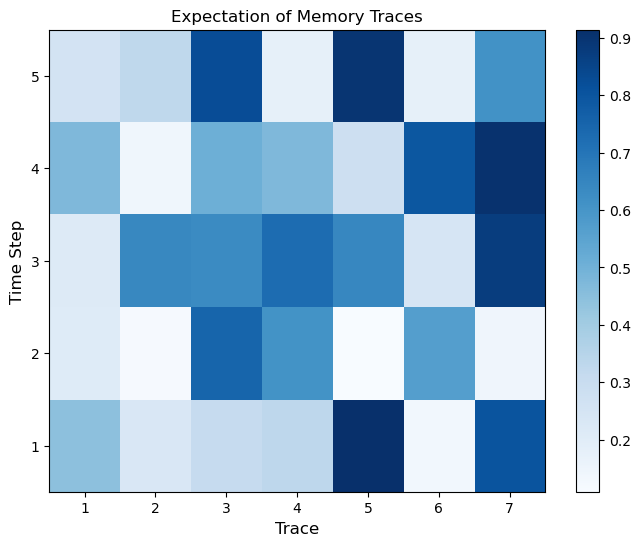

In [36]:
test_data = np.random.rand(5,7)
plot_heatmap(test_data)

In [37]:
#| export
def plot_circular_network(colors: list, highlight_index: int, ax = None, figwidth = 4) -> None:
    """
    Plot a circular network where each node is colored according to the `colors` list,
    and the node at `highlight_index` has a bright green border.
    """
    if ax is None:
        fig = plt.figure(figsize=(figwidth,figwidth))
        ax = fig.add_subplot(111)
    else:
        plt.sca(ax)  # Set current axis
    num_nodes = len(colors)
    if highlight_index >= num_nodes or highlight_index < 0:
        raise ValueError("highlight_index must be a valid index within the range of the colors list")

    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    # Optionally add edges to make it look like a circular network
    for i in range(num_nodes):
        G.add_edge(i, (i + 1) % num_nodes)

    #costum circular pos to get clockwise transitions
    angle_step = -2 * np.pi / num_nodes
    radius = 1
    pos = {
        i: ( radius * np.cos(np.pi/2 + i * angle_step), radius * np.sin(np.pi/2 + i * angle_step))
        for i in range(num_nodes)
    }

    # Draw nodes
    node_border_colors = ['lime' if i == highlight_index else 'black' for i in range(num_nodes)]
    linewidths = [3 if i == highlight_index else 0.2 for i in range(num_nodes)]
    nx.draw_networkx_nodes(
        G, pos,
        node_color=colors,
        edgecolors=node_border_colors,
        linewidths=linewidths,
        node_size=500 * figwidth  # Increased node size (display coordinates)
    )

    # Draw edges and labels (optional)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    #plt.axis('equal')  # Maintain aspect ratio
    plt.axis('off')
    if ax is None:
        plt.show()

## Example

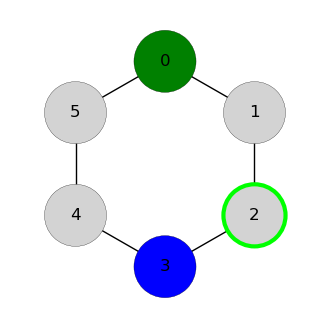

In [38]:
plot_circular_network(colors = ["green", "lightgrey", "lightgrey", "blue", "lightgrey", "lightgrey"], highlight_index = 2, figwidth = 4)

### Visualize Memory Filter Performance

In [39]:
#| export
from matplotlib.colors import ListedColormap

def plot_percepts(
    percepts, 
    colormap, 
    ax=None, 
    figsize=(2, 8), 
    tick_fontsize=10, 
    label_fontsize=12, 
    title_fontsize=14,
    title="Percepts", 
    xticks=None, 
    xtick_labels=None, 
    yticks=None, 
    ytick_labels=None, 
    **imshow_kwargs
):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        show = True
    else:
        fig = ax.figure
        show = False  # Don't show if plotting to existing axis

    T = np.shape(percepts)[0]
    n_percept_features = np.shape(percepts)[1]

    extent = (0, n_percept_features, T, 0)  # left, right, bottom, top

    if colormap is None:
        ax.imshow(percepts, aspect="auto", interpolation='nearest', extent=extent,**imshow_kwargs)
    else:
        cmap = ListedColormap(colormap)
        ax.imshow(percepts, cmap=cmap, aspect="auto", interpolation='nearest', vmin=0, vmax=len(colormap)-1, extent=extent,**imshow_kwargs)

    ax.set_title(title, fontsize=title_fontsize)
    ax.set_ylabel("Time Step", fontsize=label_fontsize)
    ax.invert_yaxis()

    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xlabel("Feature", fontsize=label_fontsize)
        if xtick_labels is not None:
            ax.set_xticklabels(xtick_labels, fontsize=tick_fontsize)
    else:
        ax.set_xticks([])

    if yticks is None:
        yticks = np.arange(T)
        ax.set_yticks(yticks + 0.5)
        # Use np.linspace to select at most 5 tick labels if ncols > 10
        if ytick_labels is None:
            if T > 10:
                idxs = np.linspace(0, T - 1, num=5, dtype=int)
                ytick_labels = [str(i+1) if i in idxs else "" for i in yticks]
            else:
                ytick_labels = [str(i+1) for i in yticks]
        ax.set_yticklabels(ytick_labels, fontsize=tick_fontsize)
    else:
        ax.set_yticks(yticks)
        if ytick_labels is not None:
            ax.set_yticklabels(ytick_labels, fontsize=tick_fontsize)

    if show:
        plt.show()
    else:
        return ax

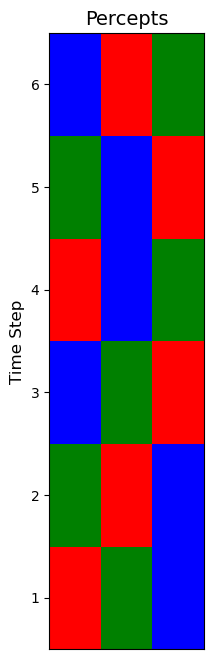

In [40]:
percepts = np.array([[0,1,2],[1,0,2],[2,1,0],[0,2,1],[1,2,0],[2,0,1]])
colormap = ['red', 'green', 'blue']
plot_percepts(percepts, colormap)

In [ ]:
#| export
def plot_surprise_bar(
    surprise, 
    T, 
    ax=None, 
    stationary_entropy=None, 
    predictive_entropy=None, 
    bar_colors=None, 
    yticks=None, 
    ytick_labels=None,
    stacked=False,
    barh_kwargs = None,
    **kwargs
):
    """
    Plot the surprise bar plot for memory filter performance.
    """
    if barh_kwargs is None:
        barh_kwargs = {}
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 8))
        show = True
    else:
        show = False

    total_surprisals = np.sum(surprise, axis=1)
    if stacked:
        y = np.arange(1, T+1)
        left = np.zeros(np.shape(surprise)[0])
        for j in range(np.shape(surprise)[1]):
            w = surprise[:, j]
            ax.barh(y, w, left=left, color=bar_colors[j] if bar_colors else None, **barh_kwargs)
            left += w
    else:
        inf_surprise_mask = total_surprisals == -1
        total_surprisals[inf_surprise_mask] = 40  # outside range of data
        ax.barh(np.arange(1, T+1), np.ravel(total_surprisals),
                color=np.where(np.ravel(total_surprisals) == 40, "red", "mediumturquoise"), **barh_kwargs)

    if stationary_entropy is not None:
        ax.axvline(x=stationary_entropy, color="red", linestyle="--", label="Stationary Entropy")
    if predictive_entropy is not None:
        ax.axvline(x=predictive_entropy, color="darkolivegreen", linestyle="--", label="Predictive Entropy")
    ax.set_title(kwargs.get("title","Surprise"), fontsize=kwargs.get("title_fontsize",14))
    ax.set_ylim(0.5, T+0.5)
    if yticks is None:
        yticks = np.arange(T) + 1
        ax.set_yticks(yticks)
        # Use np.linspace to select at most 5 tick labels if ncols > 10
        if ytick_labels is None:
            if T > 10:
                idxs = np.linspace(1, T, num=5, dtype=int)
                ytick_labels = [str(i) if i in idxs else "" for i in yticks]
            else:
                ytick_labels = [str(i) for i in yticks]
        ax.set_yticklabels(ytick_labels, fontsize=kwargs.get('tick_fontsize',10))
    else:
        ax.set_yticks(yticks)
        if ytick_labels is not None:
            ax.set_yticklabels(ytick_labels, fontsize=kwargs.get('tick_fontsize',10))
    ax.set_xlabel(kwargs.get('xlabel',"bits"))

    # Set xticks: 0, center, max+margin (including stationary_entropy if given)
    max_val = np.max(total_surprisals)
    if stationary_entropy is not None:
        max_val = max(max_val, stationary_entropy)
    margin = 0.05 * max_val if max_val > 0 else 1
    xticks = [0, max_val / 2, max_val + margin]
    xticks = kwargs.get("xticks",xticks)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=kwargs.get('tick_fontsize',10))
    if show:
        plt.show()
    else:
        return ax

In [ ]:
#| export
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def memory_filter_performance(memory_data: dict[str,Any],
                             observed_percepts: NDArray[np.int_],
                             colormap:list[str]|NDArray[np.str_]|None,
                             stationary_entropy: float|None = None,
                             predictive_entropy: float|None = None,
                             stacked: bool = False,
                             bar_colors: list[str]|None = None,
                             title: str = "Posterior Belief",
                             percept_kwargs: dict[str,Any] = {},
                             heatmap_kwargs: dict[str,Any] = {},
                             surprise_kwargs: dict[str,Any] = {},
                             **kwargs):
    T = np.shape(observed_percepts)[0]
    fig = plt.figure(figsize=(8, 6))
    nrows, ncols = 2, 3
    gs = GridSpec(nrows, ncols,
                  height_ratios=[0.99, 0.01],
                  width_ratios=[1, 8, 2],
                  figure=fig)

    axes_array = np.empty((1, ncols), dtype=object)
    for j in range(ncols):
        axes_array[0, j] = fig.add_subplot(gs[0, j])

    plot_percepts(observed_percepts, colormap, ax=axes_array[0,0], **percept_kwargs)

    # Middle plot (Posterior Belief)
    num_hypotheses = np.shape(memory_data["belief_posterior"])[1]
    hypothesis_ticks = np.arange(num_hypotheses) + 0.5
    hypothesis_tick_labels = kwargs.get("hypothesis_labels", None)
    if hypothesis_tick_labels is None:
        if num_hypotheses > 10:
            idxs = np.linspace(0, num_hypotheses - 1, num=5, dtype=int)
            hypothesis_tick_labels = [f'$h_{{{i}}}$' if i in idxs else "" for i in range(num_hypotheses)]
        else:
            hypothesis_tick_labels = [f'$h_{{{i}}}$' for i in range(num_hypotheses)]
    hypothesis_tick_labels[-1] = "$h_{*}$"

    im = plot_heatmap(
        memory_data["belief_posterior"],
        ax=axes_array[0,1],
        title=title,
        color="Oranges",
        xlabel="Hypothesis",
        xticks=hypothesis_ticks,
        xtick_labels=hypothesis_tick_labels,
        ylabel=None,
        figsize=(8, 10),
        colorbar_kwargs=None,
        **heatmap_kwargs      
    )

    # Right Plot (Surprise)
    plot_surprise_bar(
        memory_data["surprise"],
        T,
        ax=axes_array[0,2],
        stationary_entropy=stationary_entropy,
        predictive_entropy=predictive_entropy,
        bar_colors=bar_colors,
        stacked=stacked,
        barh_kwargs=surprise_kwargs
    )

    # Colorbar axis below the middle plot
    cax = fig.add_subplot(gs[1, 1])
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal', shrink=0.3, label="Hypothesis Probability")
    cbar.ax.xaxis.set_label_position('bottom')
    plt.tight_layout()